<a href="https://colab.research.google.com/github/IrisSousa/google_colab/blob/main/Desafio_Pratico_EDA_Tech_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados a partir do arquivo vendas.csv.

In [ ]:
df_vendas = pd.read_csv('/content/vendas.csv')

# Mostrar as 5 primeiras linhas do dataset.

In [ ]:
df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste


# Exibir o número total de registros (linhas).

In [ ]:
len(df_vendas)

100

# Calcular a receita total (coluna quantidade multiplicada pela coluna preco_unitario).

In [ ]:
df_vendas.columns

Index(['data', 'produto', 'categoria', 'quantidade', 'preco_unitario',
       'cliente', 'regiao'],
      dtype='object')

In [ ]:
df_vendas["Receita_total"] = df_vendas["quantidade"] * df_vendas["preco_unitario"]
df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,Receita_total
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste,2759
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte,9032
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste,4347
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte,9138
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste,8906


#Filtrar e exibir as vendas da categoria "Eletrônicos".

In [ ]:
df_vendas_filtro_eletronico = df_vendas[df_vendas["categoria"] == "Eletrônicos"]
df_vendas_filtro_eletronico.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,Receita_total
5,2025-07-24,Tablet D,Eletrônicos,2,4893,Fernanda,Sudeste,9786
6,2025-05-20,Monitor B,Eletrônicos,1,3060,Lucas,Sul,3060
9,2025-06-01,Celular A,Eletrônicos,3,516,João,Centro-Oeste,1548
10,2025-04-22,Celular A,Eletrônicos,2,1018,Fernanda,Nordeste,2036
13,2025-11-24,Notebook X,Eletrônicos,1,2670,Ana,Sul,2670


# Identificar e exibir o produto mais vendido (em quantidade).

In [ ]:
df_vendas_produto_mais_vendido = df_vendas.groupby("produto")["quantidade"].sum()
df_vendas_produto_mais_vendido.sort_values(ascending=False, inplace=True)
df_vendas_produto_mais_vendido.head(1)

,quantidade
produto,
Sofá Q,30


# Descobrir e exibir a região com maior valor de compras.

In [ ]:
df_regiao_maior_valor_compras = df_vendas.groupby("regiao")["Receita_total"].sum()
df_regiao_maior_valor_compras.sort_values(ascending=False, inplace=True)
df_regiao_maior_valor_compras

,Receita_total
regiao,
Sudeste,245605
Sul,165641
Nordeste,151802
Norte,149076
Centro-Oeste,133728


# **Desafio extra (opcional)**

# Gráfico de barras mostrando a receita por categoria.

<Axes: title={'center': 'Receita por categoria'}, xlabel='Categoria', ylabel='Receita'>

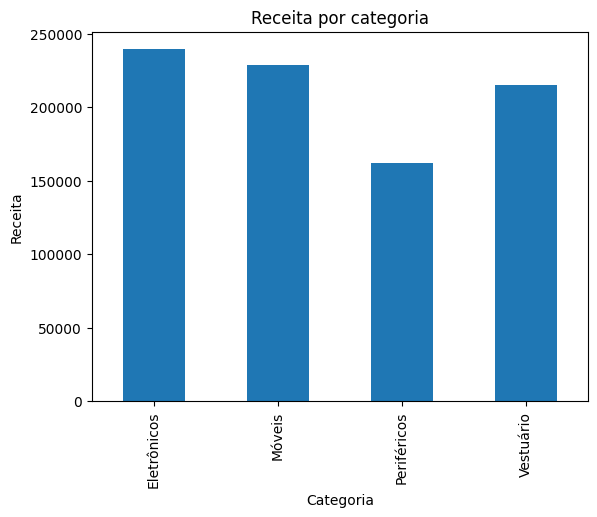

In [ ]:
df_receita_por_categoria = df_vendas.groupby("categoria")["Receita_total"].sum()
df_receita_por_categoria.plot(kind="bar", title="Receita por categoria", xlabel="Categoria", ylabel="Receita")

# Gráfico de linha mostrando a evolução das vendas por mês.

In [ ]:
df_vendas["data_corrigida"] = pd.to_datetime(df_vendas["data"])

In [ ]:
df_vendas["Mes"] = df_vendas["data_corrigida"].dt.month
df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,Receita_total,data_corrigida,Mes
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste,2759,2025-12-09,12
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte,9032,2025-03-12,3
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste,4347,2025-11-24,11
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte,9138,2025-09-14,9
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste,8906,2025-08-03,8


<Axes: title={'center': 'Evolução das Vendas ao Longo do Tempo'}, xlabel='Mês', ylabel='Receita Total'>

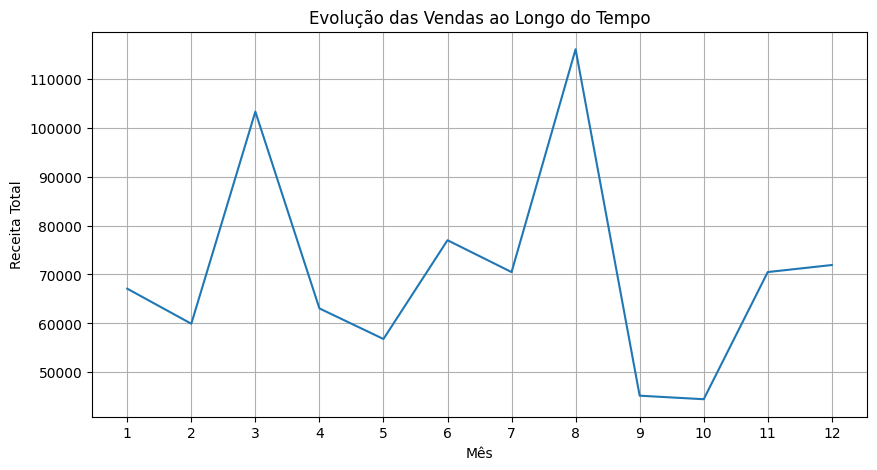

In [ ]:
evolucao_vendas_por_mes = df_vendas.groupby("Mes")["Receita_total"].sum()
evolucao_vendas_por_mes.plot(title="Evolução das Vendas ao Longo do Tempo",
                             xlabel="Mês", ylabel="Receita Total", grid=(True),
                             figsize=(10, 5), xticks=range(1, 13))